# Check DATA_FIKS

Baca `Datalog/DATA_FIKS.xlsx` (log Misc / dashboard 15 kolom + ENU/ECEF).

In [13]:
from pathlib import Path
import pandas as pd

root = Path(r"D:\Pengujian\Ship_Model_Control_ESP32-S3 v2026.01")
xlsx = root / "Datalog" / "DATA_FIKS.xlsx"

df = pd.read_excel(xlsx, sheet_name="Sheet1")
print(xlsx)
print("baris, kolom:", df.shape)
print("kolom:", list(df.columns))
df.head()

D:\Pengujian\Ship_Model_Control_ESP32-S3 v2026.01\Datalog\DATA_FIKS.xlsx
baris, kolom: (382, 24)
kolom: ['timestamp', 'latitude', 'longitude', 'speedMps', 'Calc_deg_servo_1', 'Calc_deg_servo_2', 'roll', 'pitch', 'yaw', 'zigzag_yaw', 'rpm_prop_1', 'rpm_prop_2', 'battery_1', 'battery_2', 'mode_auto', 'x_enu_flat', 'y_enu_flat', 'z_enu_flat', 'X_ecef', 'Y_ecef', 'Z_ecef', 'x_enu_ecef', 'y_enu_ecef', 'z_enu_ecef']


,timestamp,latitude,longitude,speedMps,Calc_deg_servo_1,Calc_deg_servo_2,roll,pitch,yaw,zigzag_yaw,...,mode_auto,x_enu_flat,y_enu_flat,z_enu_flat,X_ecef,Y_ecef,Z_ecef,x_enu_ecef,y_enu_ecef,z_enu_ecef
0,1993.731,-7.287184,112.796194,0.15,-40.00,-39.93,5.13,0.18,324.99,0,...,0,0.0,0.0,0,-2.451408e+06,5.832755e+06,-803647.745115,-0.0,0.0,0.0
1,1993.831,-7.287184,112.796194,0.20,-40.06,-40.11,5.14,0.18,324.87,0,...,0,0.0,0.0,0,-2.451408e+06,5.832755e+06,-803647.745115,-0.0,0.0,0.0
2,1993.931,-7.287184,112.796194,0.13,-40.41,-40.17,5.15,0.19,324.78,0,...,0,0.0,0.0,0,-2.451408e+06,5.832755e+06,-803647.745115,-0.0,0.0,0.0
3,1994.031,-7.287184,112.796194,0.16,-39.94,-39.87,5.15,0.21,324.73,0,...,0,0.0,0.0,0,-2.451408e+06,5.832755e+06,-803647.745115,-0.0,0.0,0.0
4,1994.131,-7.287184,112.796194,0.18,-40.24,-40.47,5.15,0.24,324.73,0,...,0,0.0,0.0,0,-2.451408e+06,5.832755e+06,-803647.745115,-0.0,0.0,0.0


In [14]:
df.info()
df[["timestamp", "latitude", "longitude", "speedMps", "yaw", "mode_auto"]].describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 382 entries, 0 to 381
Data columns (total 24 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   timestamp         382 non-null    float64
 1   latitude          382 non-null    float64
 2   longitude         382 non-null    float64
 3   speedMps          382 non-null    float64
 4   Calc_deg_servo_1  382 non-null    float64
 5   Calc_deg_servo_2  382 non-null    float64
 6   roll              382 non-null    float64
 7   pitch             382 non-null    float64
 8   yaw               382 non-null    float64
 9   zigzag_yaw        382 non-null    int64  
 10  rpm_prop_1        382 non-null    int64  
 11  rpm_prop_2        382 non-null    int64  
 12  battery_1         382 non-null    float64
 13  battery_2         382 non-null    float64
 14  mode_auto         382 non-null    int64  
 15  x_enu_flat        382 non-null    float64
 16  y_enu_flat        382 non-null    float64
 1

,timestamp,latitude,longitude,speedMps,yaw,mode_auto
count,382.000000,382.000000,382.000000,382.000000,382.000000,382.000000
mean,2012.887283,-7.287173,112.796127,0.611440,160.963063,0.727749
std,11.160892,0.000013,0.000032,0.140706,131.267766,0.445702
min,1993.731000,-7.287188,112.796088,0.130000,0.020000,0.000000
25%,2003.256000,-7.287183,112.796102,0.550000,20.520000,0.000000
50%,2012.781000,-7.287178,112.796120,0.610000,142.195000,1.000000
75%,2022.606000,-7.287163,112.796150,0.700000,304.400000,1.000000
max,2032.131000,-7.287147,112.796194,0.920000,359.100000,1.000000


Yaw di file ini sudah 0–360 (bukan −180…180). Konvensi HWT905 setelah wrap Remote/Send: **0 = Utara, 270 ≈ Timur, 90 ≈ Barat**.

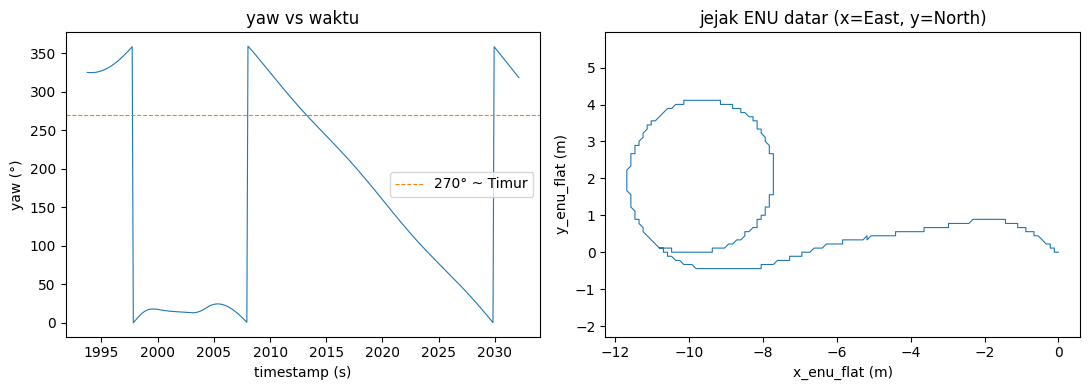

In [15]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(1, 2, figsize=(11, 4))
ax[0].plot(df["timestamp"], df["yaw"], lw=0.8)
ax[0].set_title("yaw vs waktu")
ax[0].set_xlabel("timestamp (s)")
ax[0].set_ylabel("yaw (°)")
ax[0].axhline(270, color="C1", ls="--", lw=0.8, label="270° ~ Timur")
ax[0].legend()

ax[1].plot(df["x_enu_flat"], df["y_enu_flat"], lw=0.8)
ax[1].set_title("jejak ENU datar (x=East, y=North)")
ax[1].set_xlabel("x_enu_flat (m)")
ax[1].set_ylabel("y_enu_flat (m)")
ax[1].axis("equal")
fig.tight_layout()
plt.show()

Bandingkan ENU datar rumus 1.2 / Remote (`R = 6 371 000` m) dengan kolom `x_enu_flat`, `y_enu_flat`.

Origin = baris pertama file: **lat0 = −7.287184**, **lon0 = 112.796194**.

```text
x = (lon − lon0) × (π/180) × R × cos(lat0)   // East
y = (lat − lat0) × (π/180) × R                 // North
```

origin lat0=-7.287184  lon0=112.796194
RMSE x  0.000000 m   max |dx| 0.000000 m
RMSE y  0.000000 m   max |dy| 0.000000 m


,timestamp,latitude,longitude,x_calc,x_enu_flat,dx_enu,y_calc,y_enu_flat,dy_enu
0,1993.731,-7.287184,112.796194,0.000000,0.000000,0.000000e+00,0.000000,0.000000,0.000000e+00
1,1993.831,-7.287184,112.796194,0.000000,0.000000,0.000000e+00,0.000000,0.000000,0.000000e+00
2,1993.931,-7.287184,112.796194,0.000000,0.000000,0.000000e+00,0.000000,0.000000,0.000000e+00
3,1994.031,-7.287184,112.796194,0.000000,0.000000,0.000000e+00,0.000000,0.000000,0.000000e+00
4,1994.131,-7.287184,112.796194,0.000000,0.000000,0.000000e+00,0.000000,0.000000,0.000000e+00
5,1994.231,-7.287184,112.796193,-0.110297,-0.110297,1.387779e-17,0.000000,0.000000,0.000000e+00
6,1994.331,-7.287183,112.796193,-0.110297,-0.110297,1.387779e-17,0.111195,0.111195,3.330669e-16
7,1994.431,-7.287183,112.796193,-0.110297,-0.110297,1.387779e-17,0.111195,0.111195,3.330669e-16


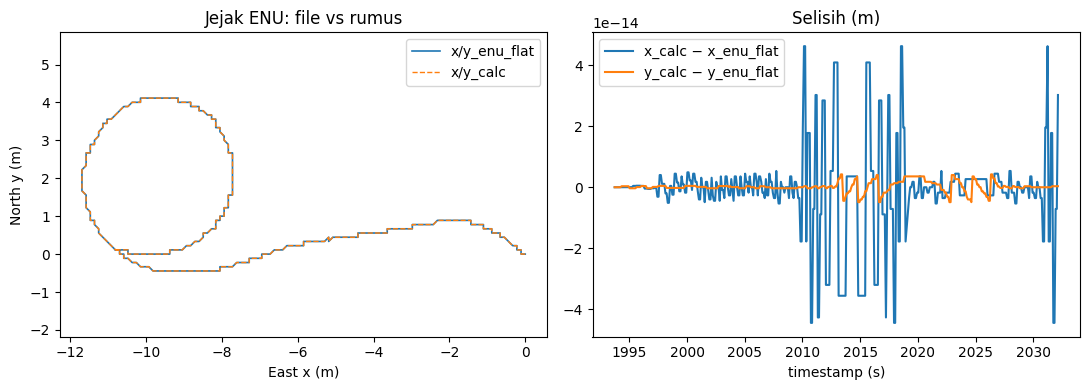

In [16]:
import numpy as np

R = 6_371_000.0
lat0 = float(df.iloc[0]["latitude"])   # -7.287184
lon0 = float(df.iloc[0]["longitude"])  # 112.796194
lat0_rad = np.deg2rad(lat0)

df["x_calc"] = np.deg2rad(df["longitude"] - lon0) * R * np.cos(lat0_rad)
df["y_calc"] = np.deg2rad(df["latitude"] - lat0) * R
df["dx_enu"] = df["x_calc"] - df["x_enu_flat"]
df["dy_enu"] = df["y_calc"] - df["y_enu_flat"]

print(f"origin lat0={lat0:.6f}  lon0={lon0:.6f}")
print(f"RMSE x  {np.sqrt(np.mean(df['dx_enu']**2)):.6f} m   max |dx| {df['dx_enu'].abs().max():.6f} m")
print(f"RMSE y  {np.sqrt(np.mean(df['dy_enu']**2)):.6f} m   max |dy| {df['dy_enu'].abs().max():.6f} m")

display(df[["timestamp", "latitude", "longitude", "x_calc", "x_enu_flat", "dx_enu", "y_calc", "y_enu_flat", "dy_enu"]].head(8))

fig, ax = plt.subplots(1, 2, figsize=(11, 4))
ax[0].plot(df["x_enu_flat"], df["y_enu_flat"], label="x/y_enu_flat", lw=1.2)
ax[0].plot(df["x_calc"], df["y_calc"], "--", label="x/y_calc", lw=1.0)
ax[0].set_title("Jejak ENU: file vs rumus")
ax[0].set_xlabel("East x (m)")
ax[0].set_ylabel("North y (m)")
ax[0].axis("equal")
ax[0].legend()

ax[1].plot(df["timestamp"], df["dx_enu"], label="x_calc − x_enu_flat")
ax[1].plot(df["timestamp"], df["dy_enu"], label="y_calc − y_enu_flat")
ax[1].set_title("Selisih (m)")
ax[1].set_xlabel("timestamp (s)")
ax[1].legend()
fig.tight_layout()
plt.show()

Langkah 2 — kecepatan peta dari Δposisi (sama 1.2, α = 0.70).

```text
Δt = timestamp_k − timestamp_{k-1}
ẋ_raw = (x_k − x_{k-1}) / Δt
ẏ_raw = (y_k − y_{k-1}) / Δt
ẋ = 0.70 · ẋ_lama + 0.30 · ẋ_raw
ẏ = 0.70 · ẏ_lama + 0.30 · ẏ_raw
|V| = √(ẋ² + ẏ²)
```

`ẋ > 0` ke timur, `ẏ > 0` ke utara. Yaw IMU: **0 ~ Utara**, **270 ~ Timur** (bukan 90 = Timur).

sampel vel_ok=381 / 382  α=0.7
ẋ  mean=-0.283  min=-0.984  max=0.785 m/s  (+ = timur)
ẏ  mean=0.001  min=-0.785  max=0.819 m/s  (+ = utara)
--- banding |V| vs speedMps ---
|V|      mean=0.633  min=0.000  max=1.029 m/s
speedMps mean=0.613  min=0.130  max=0.920 m/s
|V|-speedMps  RMSE=0.122  MAE=0.103  max|d|=0.336  corr=0.733


,timestamp,x_dot,y_dot,V_enu,speedMps,dV_speed,yaw
0,1993.731,0.000000,0.000000,0.000000,0.15,-0.150000,324.99
1,1993.831,0.000000,0.000000,0.000000,0.20,-0.200000,324.87
2,1993.931,0.000000,0.000000,0.000000,0.13,-0.130000,324.78
3,1994.031,0.000000,0.000000,0.000000,0.16,-0.160000,324.73
4,1994.131,0.000000,0.000000,0.000000,0.18,-0.180000,324.73
5,1994.231,-0.330890,0.000000,0.330890,0.19,0.140890,324.78
6,1994.331,-0.231623,0.333585,0.406113,0.18,0.226113,324.89
7,1994.431,-0.162136,0.233509,0.284279,0.18,0.104279,325.06


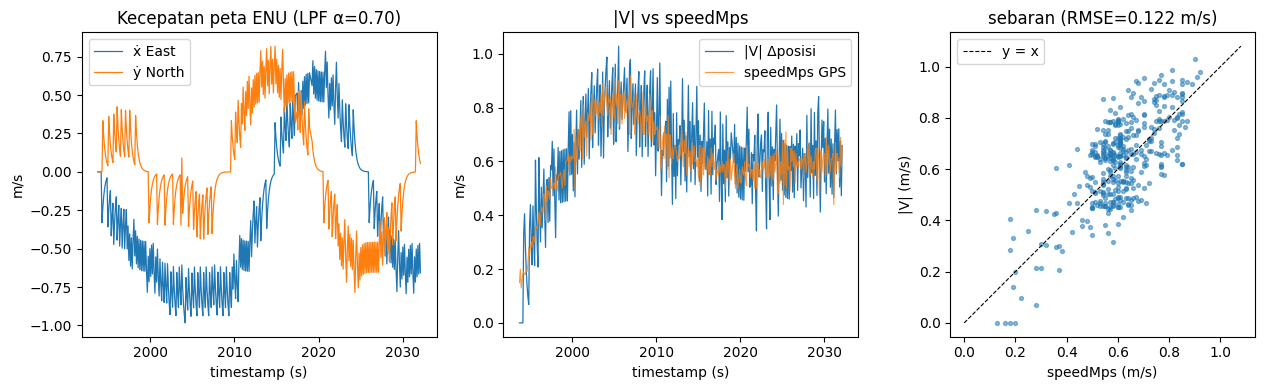

In [17]:
alpha = 0.70
min_dt, max_dt = 0.001, 1.0

x = df["x_calc"] if "x_calc" in df.columns else df["x_enu_flat"]
y = df["y_calc"] if "y_calc" in df.columns else df["y_enu_flat"]
t = df["timestamp"].to_numpy()

n = len(df)
x_dot = np.zeros(n)
y_dot = np.zeros(n)
speed_v = np.zeros(n)
vel_ok = np.zeros(n, dtype=bool)

for k in range(1, n):
    dt = t[k] - t[k - 1]
    if dt < min_dt or dt > max_dt:
        x_dot[k] = 0.0
        y_dot[k] = 0.0
        continue
    x_raw = (x.iloc[k] - x.iloc[k - 1]) / dt
    y_raw = (y.iloc[k] - y.iloc[k - 1]) / dt
    x_dot[k] = alpha * x_dot[k - 1] + (1.0 - alpha) * x_raw
    y_dot[k] = alpha * y_dot[k - 1] + (1.0 - alpha) * y_raw
    speed_v[k] = np.hypot(x_dot[k], y_dot[k])
    vel_ok[k] = True

df["x_dot"] = x_dot
df["y_dot"] = y_dot
df["V_enu"] = speed_v
df["dV_speed"] = df["V_enu"] - df["speedMps"]

ok = vel_ok
v_ok = df.loc[ok, "V_enu"]
s_ok = df.loc[ok, "speedMps"]
d_ok = df.loc[ok, "dV_speed"]
rmse = float(np.sqrt(np.mean(d_ok**2)))
mae = float(np.mean(np.abs(d_ok)))
corr = float(np.corrcoef(v_ok, s_ok)[0, 1]) if len(v_ok) > 1 else float("nan")

print(f"sampel vel_ok={ok.sum()} / {n}  α={alpha}")
print(f"ẋ  mean={x_dot[ok].mean():.3f}  min={x_dot[ok].min():.3f}  max={x_dot[ok].max():.3f} m/s  (+ = timur)")
print(f"ẏ  mean={y_dot[ok].mean():.3f}  min={y_dot[ok].min():.3f}  max={y_dot[ok].max():.3f} m/s  (+ = utara)")
print("--- banding |V| vs speedMps ---")
print(f"|V|      mean={v_ok.mean():.3f}  min={v_ok.min():.3f}  max={v_ok.max():.3f} m/s")
print(f"speedMps mean={s_ok.mean():.3f}  min={s_ok.min():.3f}  max={s_ok.max():.3f} m/s")
print(f"|V|-speedMps  RMSE={rmse:.3f}  MAE={mae:.3f}  max|d|={d_ok.abs().max():.3f}  corr={corr:.3f}")

display(df[["timestamp", "x_dot", "y_dot", "V_enu", "speedMps", "dV_speed", "yaw"]].head(8))

fig, ax = plt.subplots(1, 3, figsize=(13, 4))
ax[0].plot(df["timestamp"], df["x_dot"], label="ẋ East", lw=0.9)
ax[0].plot(df["timestamp"], df["y_dot"], label="ẏ North", lw=0.9)
ax[0].set_title("Kecepatan peta ENU (LPF α=0.70)")
ax[0].set_xlabel("timestamp (s)")
ax[0].set_ylabel("m/s")
ax[0].legend()

ax[1].plot(df["timestamp"], df["V_enu"], label="|V| Δposisi", lw=0.9)
ax[1].plot(df["timestamp"], df["speedMps"], label="speedMps GPS", lw=0.8, alpha=0.8)
ax[1].set_title("|V| vs speedMps")
ax[1].set_xlabel("timestamp (s)")
ax[1].set_ylabel("m/s")
ax[1].legend()

lim = [0, max(v_ok.max(), s_ok.max()) * 1.05]
ax[2].scatter(s_ok, v_ok, s=8, alpha=0.5)
ax[2].plot(lim, lim, "k--", lw=0.8, label="y = x")
ax[2].set_title(f"sebaran (RMSE={rmse:.3f} m/s)")
ax[2].set_xlabel("speedMps (m/s)")
ax[2].set_ylabel("|V| (m/s)")
ax[2].set_aspect("equal", adjustable="box")
ax[2].legend()
fig.tight_layout()
plt.show()

Langkah 3 — rotasi ke badan: surge `u` dan sway `v`.

README 1.2 (asumsi kompas **90° = Timur**):

```text
u =  ẋ sinψ + ẏ cosψ     // surge
v =  ẋ cosψ − ẏ sinψ     // sway
```

Vektor maju di peta: `(sinψ, cosψ)`. Cek: `ψ=90°` → maju = `+x` (timur).

IMU lapangan: **0° = Utara**, **270° = Timur** (90° = Barat). Vektor maju jadi `(-sinψ, cosψ)`.

```text
u = −ẋ sinψ + ẏ cosψ     // surge (0=N, 270=E)
v =  ẋ cosψ + ẏ sinψ     // sway  kanan +
```

Setara: pakai rumus README dengan `ψ' = −ψ` (atau `360° − yaw`).

| yaw | haluan | rumus 1.2 (`90=E`) | rumus IMU (`270=E`) |
|----:|--------|--------------------|---------------------|
| 0° | Utara | `u=ẏ`, `v=ẋ` | sama |
| 90° | Barat (IMU) / Timur (1.2) | `u=ẋ` | `u=−ẋ` |
| 270° | Timur (IMU) / Barat (1.2) | `u=−ẋ` | `u=ẋ` |

Cek `ψ=0`: tetap `u=ẏ`, `v=ẋ`. Cek `ψ=270°` (haluan timur IMU): `u=ẋ`, `v=−ẏ`.

In [ ]:
psi = np.deg2rad(df["yaw"].to_numpy())
sin_p = np.sin(psi)
cos_p = np.cos(psi)

# rumus README 1.2 (asumsi 90° = Timur) — salah untuk IMU ini
df["u_readme"] = df["x_dot"] * sin_p + df["y_dot"] * cos_p
df["v_readme"] = df["x_dot"] * cos_p - df["y_dot"] * sin_p

# rumus lapangan: 0° = Utara, 270° = Timur  (= rumus 1.2 dengan ψ' = −ψ)
df["u"] = -df["x_dot"] * sin_p + df["y_dot"] * cos_p
df["v"] = df["x_dot"] * cos_p + df["y_dot"] * sin_p
df["V_body"] = np.hypot(df["u"], df["v"])

ok = df["V_enu"] > 0
print("--- u,v  (0=Utara, 270=Timur) ---")
print(f"u  mean={df.loc[ok, 'u'].mean():.3f}  min={df.loc[ok, 'u'].min():.3f}  max={df.loc[ok, 'u'].max():.3f} m/s  (maju +)")
print(f"v  mean={df.loc[ok, 'v'].mean():.3f}  min={df.loc[ok, 'v'].min():.3f}  max={df.loc[ok, 'v'].max():.3f} m/s  (kanan +)")
print(f"|u,v| mean={df.loc[ok, 'V_body'].mean():.3f}  |V| mean={df.loc[ok, 'V_enu'].mean():.3f}  (harus ≈ sama)")
print(f"max | |u,v| − |V| | = {np.abs(df.loc[ok, 'V_body'] - df.loc[ok, 'V_enu']).max():.2e} m/s")
print("--- beda vs rumus README (90=Timur) ---")
print(f"max |u − u_readme| = {np.abs(df.loc[ok, 'u'] - df.loc[ok, 'u_readme']).max():.3f} m/s")
print(f"max |v − v_readme| = {np.abs(df.loc[ok, 'v'] - df.loc[ok, 'v_readme']).max():.3f} m/s")
print(f"u vs speedMps  RMSE={np.sqrt(np.mean((df.loc[ok, 'u'] - df.loc[ok, 'speedMps'])**2)):.3f} m/s")

display(df[["timestamp", "yaw", "x_dot", "y_dot", "u", "v", "u_readme", "v_readme", "V_enu", "speedMps"]].head(8))

fig, ax = plt.subplots(1, 3, figsize=(13, 4))
ax[0].plot(df["timestamp"], df["u"], label="u surge (270=E)", lw=0.9)
ax[0].plot(df["timestamp"], df["v"], label="v sway", lw=0.9)
ax[0].set_title("u, v badan (IMU 0=N, 270=E)")
ax[0].set_xlabel("timestamp (s)")
ax[0].set_ylabel("m/s")
ax[0].legend()

ax[1].plot(df["timestamp"], df["u"], label="u IMU", lw=0.9)
ax[1].plot(df["timestamp"], df["u_readme"], label="u README 90=E", lw=0.8, alpha=0.8)
ax[1].plot(df["timestamp"], df["speedMps"], label="speedMps", lw=0.7, alpha=0.7)
ax[1].set_title("surge: rumus IMU vs 1.2")
ax[1].set_xlabel("timestamp (s)")
ax[1].set_ylabel("m/s")
ax[1].legend()

ax[2].plot(df["timestamp"], df["yaw"], lw=0.8, color="tab:purple")
ax[2].axhline(270, color="gray", ls="--", lw=0.7, label="270° Timur")
ax[2].axhline(0, color="gray", ls=":", lw=0.7, label="0° Utara")
ax[2].set_title("yaw IMU")
ax[2].set_xlabel("timestamp (s)")
ax[2].set_ylabel("deg")
ax[2].legend()
fig.tight_layout()
plt.show()

Langkah 4 — `yaw` IMU → `ψ` NMPC (sama 2.0).

NMPC: `0` = Timur, naik CCW. IMU: **0 = Utara, 270° = Timur**.

```text
ψ_nmpc = wrap(π/2 + yaw·π/180)
r_nd   = yaw_rate·π/180 · L / u0     // tanpa minus
```

| yaw IMU | haluan | `ψ` NMPC |
|--------:|--------|-----------|
| 0° | Utara | +90° |
| 90° | Barat | +180° / −180° |
| 180° | Selatan | −90° |
| 270° | Timur | 0° |

`u`, `v` di langkah 3 tetap kecepatan badan (surge/sway), bukan state NMPC (`v=0` di 2.0).

In [ ]:
yaw_rad = np.deg2rad(df["yaw"].to_numpy())
psi_nmpc = np.arctan2(np.sin(np.pi / 2 + yaw_rad), np.cos(np.pi / 2 + yaw_rad))
psi_nmpc_deg = np.rad2deg(psi_nmpc)
psi_old = np.arctan2(np.sin(np.pi / 2 - yaw_rad), np.cos(np.pi / 2 - yaw_rad))

df["psi_nmpc_deg"] = psi_nmpc_deg

print("--- yaw IMU → ψ NMPC (2.0: π/2 + yaw) ---")
print(f"yaw     mean={df['yaw'].mean():.1f}  min={df['yaw'].min():.1f}  max={df['yaw'].max():.1f} °")
print(f"ψ NMPC  mean={psi_nmpc_deg.mean():.1f}  min={psi_nmpc_deg.min():.1f}  max={psi_nmpc_deg.max():.1f} °")
print(f"max |ψ_baru − ψ_lama(π/2−yaw)| = {np.max(np.abs(np.rad2deg(psi_nmpc - psi_old))):.1f} °")

# cek titik cardinal di data (jika ada)
for y0, nama, expect in [(0, "Utara", 90.0), (90, "Barat", 180.0), (180, "Selatan", -90.0), (270, "Timur", 0.0)]:
    near = np.abs(((df["yaw"] - y0 + 180) % 360) - 180) < 8
    if near.any():
        got = psi_nmpc_deg[near.to_numpy()].mean()
        print(f"  yaw≈{y0:.0f}° ({nama}): ψ NMPC mean={got:.1f}°  (harap ≈ {expect:.0f}°)")

display(df[["timestamp", "yaw", "psi_nmpc_deg", "u", "v", "speedMps"]].head(8))

fig, ax = plt.subplots(1, 2, figsize=(11, 4))
ax[0].plot(df["timestamp"], df["yaw"], label="yaw IMU", lw=0.9)
ax[0].plot(df["timestamp"], psi_nmpc_deg, label="ψ NMPC (π/2+yaw)", lw=0.9)
ax[0].axhline(0, color="gray", ls=":", lw=0.6)
ax[0].set_title("yaw IMU vs ψ NMPC")
ax[0].set_xlabel("timestamp (s)")
ax[0].set_ylabel("deg")
ax[0].legend()

ax[1].plot(df["timestamp"], df["u"], label="u surge", lw=0.9)
ax[1].plot(df["timestamp"], df["v"], label="v sway", lw=0.9)
ax[1].plot(df["timestamp"], df["speedMps"], label="speedMps", lw=0.7, alpha=0.7)
ax[1].set_title("u, v (langkah 3) vs speedMps")
ax[1].set_xlabel("timestamp (s)")
ax[1].set_ylabel("m/s")
ax[1].legend()
fig.tight_layout()
plt.show()